In [119]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.constants import mu_0


In [120]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


In [121]:
def conversion(I):
    """
    Convierte corriente en amperios → campo B en teslas.
    Usa promedios de calibración en mT/A.
    """
    valores = np.array([0.1/0.14, 25.4/1.49, 56.3/3.14])
    promedio_conversion = np.mean(valores)  

    B_mT = I * promedio_conversion       
    return B_mT * 1e-3                      

def B_to_H(B_tesla):
    """
    Convierte campo B (teslas) → campo H (A/m)
    """
    return B_tesla / mu_0 



In [ ]:
def plot_secuencia_datos(
        x, y,
        titulo="Secuencia de Toma de Datos",
        xlabel="Posición X",
        ylabel="Posición Y",
        color_arrows="black",
        color_points="#D6259B",
        arrow_scale=0.25,   # tamaño relativo de flechas
        point_size=40,
        xlim=None,
        ylim=None):

    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor("#F7F9FB")

    # Dibujar flechas pequeñas y finas
    for i in range(len(x) - 1):
        ax.annotate(
            "",
            xy=(x[i+1], y[i+1]),
            xytext=(x[i], y[i]),
            arrowprops=dict(
                arrowstyle="-|>", 
                lw=1.2,
                color=color_arrows,
                shrinkA=arrow_scale,
                shrinkB=arrow_scale
            )
        )
    
    # Puntos
    ax.scatter(
        x, y,
        s=point_size,
        color=color_points,
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
    )
    

    ax.set_title(titulo, fontsize=16, weight="bold")
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, alpha=0.25)
    
    # Límites opcionales
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    
    # Bordes sutiles
    for spine in ax.spines.values():
        spine.set_color("#444")
        spine.set_linewidth(0.8)

    plt.show()


In [123]:
hierro = leer_columnas('Hierro.txt')
niquel = leer_columnas('Niquel.txt')

In [ ]:
# Errores instrumentales
SIGMA_I = 0.01 ; SIGMA_B = 0.01e-3   

def ajustar_campo_magnetico(I_datos, B_datos):
    I_cal = np.array([0.14, 1.49, 3.14]);  B_cal = np.array([0.1, 25.4, 56.3]) * 1e-3         


    I_all = np.concatenate([I_datos, I_cal])
    B_all = np.concatenate([B_datos, B_cal])

    # ==========================
    # 3) PESOS (1/sigma^2)
    # ==========================
    # Para tus datos: error instrumental
    sigma_B_datos = np.full_like(I_datos, SIGMA_B, dtype=float)

    # Para calibración: más peso (menor incertidumbre)
    factor_mas_peso = 0.5  # la mitad de la incertidumbre → 4 veces más peso
    sigma_B_cal = np.full_like(I_cal, SIGMA_B * factor_mas_peso, dtype=float)

    sigma_all = np.concatenate([sigma_B_datos, sigma_B_cal])
    w = 1.0 / sigma_all**2  # ¡CORRECCIÓN: pesos son 1/sigma^2!

    # ==========================
    # 4) AJUSTE LINEAL PONDERADO
    # ==========================
    # B = m I + b
    coef, cov = np.polyfit(I_all, B_all, 1, w=w, cov=True)
    pendiente, intercepto = coef
    sigma_m = np.sqrt(cov[0, 0])
    sigma_b = np.sqrt(cov[1, 1])

    # ==========================
    # 5) RESIDUALES Y ESTADÍSTICAS
    # ==========================
    B_ajus_all = np.polyval(coef, I_all)
    residuales = B_all - B_ajus_all
    chi2 = np.sum((residuales / sigma_all)**2)
    grados_libertad = len(I_all) - 2
    chi2_reducido = chi2 / grados_libertad

    # ==========================
    # 6) FIGURA: ajuste + residuales
    # ==========================
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}
    )

    # --- Puntos de tus datos ---
    ax1.errorbar(I_datos, B_datos, yerr=sigma_B_datos, fmt='o', 
                 color="royalblue", markersize=5, capsize=3,
                 label="Datos lab (I, B)")

    # --- Puntos de calibración ---
    ax1.errorbar(I_cal, B_cal, yerr=sigma_B_cal, fmt='s', 
                 color="darkred", markersize=6, capsize=4,
                 label="Calibración teslámetro")

    # --- Recta ajustada ---
    I_line = np.linspace(0, 1.1 * I_all.max(), 300)
    B_line = np.polyval(coef, I_line)
    ax1.plot(I_line, B_line, "black", linewidth=2, label="Ajuste lineal")

    # Estética general
    ax1.set_title("Ajuste lineal ponderado del campo magnético", fontsize=14, weight="bold")
    ax1.set_xlabel("Corriente I (A)", fontsize=12)
    ax1.set_ylabel("Campo B (T)", fontsize=12)
    ax1.grid(alpha=0.3)
    ax1.legend()

    # --- Texto con parámetros ---
    texto_param = f"Pendiente: ({pendiente:.4f} ± {sigma_m:.4f}) T/A\n"
    texto_param += f"Intercepto: ({intercepto:.5f} ± {sigma_b:.5f}) T\n"
    texto_param += f"χ²/ν = {chi2_reducido:.2f}"
    
    ax1.text(0.05, 0.95, texto_param, transform=ax1.transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # --- Residuales ---
    ax2.errorbar(I_all, residuales, yerr=sigma_all, fmt='o', 
                 color="purple", markersize=4, capsize=3, alpha=0.7)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_xlabel("Corriente I (A)")
    ax2.set_ylabel("Residuales (T)")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ==========================
    # 7) IMPRIMIR RESULTADOS
    # ==========================
    print("=" * 50)
    print("RESULTADOS DEL AJUSTE LINEAL")
    print("=" * 50)
    print(f"Pendiente (m): {pendiente:.6f} ± {sigma_m:.6f} T/A")
    print(f"Intercepto (b): {intercepto:.6f} ± {sigma_b:.6f} T")
    print(f"χ² = {chi2:.2f}")
    print(f"Grados de libertad = {grados_libertad}")
    print(f"χ² reducido = {chi2_reducido:.2f}")
    print("=" * 50)

    return pendiente, sigma_m, intercepto, sigma_b

'\n# Datos de ejemplo - reemplaza con tus datos reales\nI_tus_datos = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])\nB_tus_datos = np.array([0.008, 0.018, 0.028, 0.038, 0.048, 0.058])\n\n# Llamar a la función\npend, sigma_pend, inter, sigma_inter = ajustar_campo_magnetico(I_tus_datos, B_tus_datos)\n'

C:\Users\user\AppData\Local\Temp\ipykernel_16808\394572954.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=True, facecolor="white", edgecolor="gray")


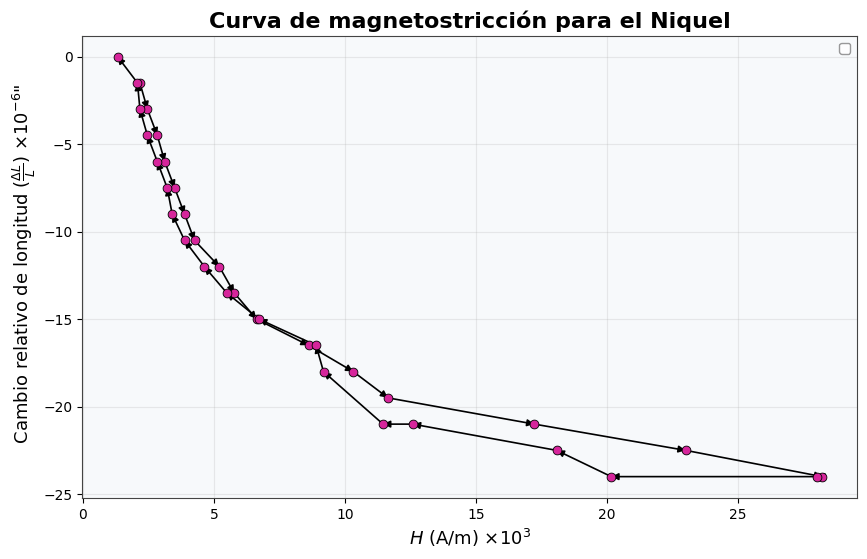

In [125]:
lambda_n = 6*10**-9 #nm
delta_l = lambda_n *niquel[1] / 2 
l= 0.1

H = B_to_H(conversion(niquel[0]))


plot_secuencia_datos(
    H*10**-3, delta_l/l*10**8,
    titulo="Curva de magnetostricción para el Niquel",
    xlabel = r"$H$ (A/m) $\times 10^{3}$",
    ylabel= r' Cambio relativo de longitud ($\frac{\Delta L}{L}$) $\times 10^{-6}$"',
    arrow_scale=0.15,
)
